## 1. What this notebook computes

The field dirac16complex of this book has 16 components that **anticommute**: for
two of its components $\Psi_A \Psi_B = -\Psi_B \Psi_A$. Ordinary numbers cannot do
that. This notebook builds, from nothing but its rules, the algebra of such numbers
(a **Grassmann algebra**) in a few lines of plain Python, and then uses it. It

- writes a program that multiplies anticommuting symbols and checks the rules
  $\theta_i \theta_j = -\theta_j \theta_i$ and $\theta_i^2 = 0$;
- counts how many independent products a Grassmann algebra has ($2^n$ for $n$
  symbols) and draws the multiplication table of three symbols;
- shows which elements commute and which anticommute (even and odd elements);
- builds the **conjugation**, which reverses the order of a product, and the
  **left and right derivatives**;
- shows that a bilinear form $\Psi^\dagger M \Psi$ is real exactly when the matrix
  $M$ is Hermitian, for anticommuting components as for ordinary numbers;
- shows, with the author's matrix $C$ read from the Revision record, that for a
  REAL anticommuting column the form $\Theta^T C \Theta$ is zero while every
  $\Theta^T C \gamma^{(a)} \Theta$ survives, and that for real ordinary numbers it is
  the other way round;
- computes every power of the scalar density $S = \bar\Psi \Psi = \Psi^\dagger C
  \Psi$ of a 16-component complex anticommuting field: $S^k$ has
  $\binom{16}{k}$ monomials, each with coefficient $\pm k!$, and $S^{17} = 0$;
- reproduces the Grassmann-algebra facts that the Revision record verifies
  (Revision/theory/reports/python-field-theory.json and
  Revision/theory/reports/wolfram-field-theory.json);
- derives the Euler-Lagrange equation of a small anticommuting oscillator, and
  shows that a first-order kinetic term of REAL anticommuting fields gives no
  field equation at all.

Every result is checked by a line that starts with PASS; the last line counts the
checks. Seven figures are drawn and saved.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 07a (A Grassmann algebra by hand) is the file
`Revision/textbook/notebooks/07a_grassmann_algebra.ipynb` of the repository Dirac_claude.
It builds a Grassmann algebra (numbers that anticommute) from its rules in a few lines of
plain Python, checks the rules, the order-reversing conjugation and the left and right
derivatives, shows which bilinear forms of a real anticommuting column survive with the
author's charge matrix C, counts the monomials of every power of the scalar density S of
a 16-component complex Grassmann field (the 17th power is zero), reproduces the
Grassmann-algebra facts of the Revision record, derives two Euler-Lagrange equations with
Grassmann variables and draws seven teaching plots. It needs a computer with Windows 11,
macOS or Linux, an internet connection for the installation, the program Git, and Python
3.12 or newer (the notebooks were built with Python 3.14.5) with these packages at
exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 07a_grassmann_algebra.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 20 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 07a_grassmann_algebra.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
07a_grassmann_algebra.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:
`Revision/textbook/figures/07a.captions.json`,
`Revision/textbook/figures/07a_1_dimension_and_degrees.png`,
`Revision/textbook/figures/07a_2_multiplication_signs.png`,
`Revision/textbook/figures/07a_3_commutation_signs.png`,
`Revision/textbook/figures/07a_4_bilinear_survivors.png`,
`Revision/textbook/figures/07a_5_symmetric_antisymmetric.png`,
`Revision/textbook/figures/07a_6_powers_of_s.png` and
`Revision/textbook/figures/07a_7_oscillator_solution.png`. It changes no other file of
the repository; running it headless or saving it in JupyterLab also rewrites the notebook
file itself. It does not use the internet while it runs. The files it writes are the same
files that are stored in the repository (on another computer a figure may differ in a few
bytes, which is harmless). To get the stored versions back, run this command in the
repository folder (it also undoes every change you made yourself in the folder
Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all 7 figure files of this notebook exist
    ALL 38 CHECKS PASSED (notebook 07a)

and the notebook must show 7 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/07a_grassmann_algebra.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "ValueError: ... is not a passing check of Revision/theory/reports/...": the Revision
  record files of your copy of the repository differ from the committed ones; restore
  them with the command below (run in the repository folder) and run the notebook again.

      git restore Revision/theory/reports Revision/algebra

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 07a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 07a (A Grassmann algebra by hand) is the file
# Revision/textbook/notebooks/07a_grassmann_algebra.ipynb of the repository Dirac_claude.
# It builds a Grassmann algebra (numbers that anticommute) from its rules in a few lines
# of plain Python, checks the rules, the order-reversing conjugation and the left and
# right derivatives, shows which bilinear forms of a real anticommuting column survive
# with the author's charge matrix C, counts the monomials of every power of the scalar
# density S of a 16-component complex Grassmann field (the 17th power is zero),
# reproduces the Grassmann-algebra facts of the Revision record, derives two
# Euler-Lagrange equations with Grassmann variables and draws seven teaching plots. It
# needs a computer with Windows 11, macOS or Linux, an internet connection for the
# installation, the program Git, and Python 3.12 or newer (the notebooks were built with
# Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
# 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
# 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy
# and matplotlib; the other packages run Jupyter, the program that shows and runs
# notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 07a_grassmann_algebra.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 20
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 07a_grassmann_algebra.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 07a_grassmann_algebra.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
# Revision/textbook/figures/07a.captions.json,
# Revision/textbook/figures/07a_1_dimension_and_degrees.png,
# Revision/textbook/figures/07a_2_multiplication_signs.png,
# Revision/textbook/figures/07a_3_commutation_signs.png,
# Revision/textbook/figures/07a_4_bilinear_survivors.png,
# Revision/textbook/figures/07a_5_symmetric_antisymmetric.png,
# Revision/textbook/figures/07a_6_powers_of_s.png and
# Revision/textbook/figures/07a_7_oscillator_solution.png. It changes no other file of
# the repository; running it headless or saving it in JupyterLab also rewrites the
# notebook file itself. It does not use the internet while it runs. The files it writes
# are the same files that are stored in the repository (on another computer a figure may
# differ in a few bytes, which is harmless). To get the stored versions back, run this
# command in the repository folder (it also undoes every change you made yourself in the
# folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all 7 figure files of this notebook exist
#     ALL 38 CHECKS PASSED (notebook 07a)
#
# and the notebook must show 7 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/07a_grassmann_algebra.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "ValueError: ... is not a passing check of Revision/theory/reports/...": the Revision
#   record files of your copy of the repository differ from the committed ones; restore
#   them with the command below (run in the repository folder) and run the notebook
#   again.
#     git restore Revision/theory/reports Revision/algebra
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "07a"  # this notebook: chapter 07, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 07a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Generator**: one of the anticommuting symbols $\theta_0, \theta_1, \dots,
  \theta_{n-1}$ from which everything is built. In the program a generator is
  named by its number $0, 1, \dots, n-1$.
- **Anticommute**: $xy = -yx$. Two different generators anticommute; a generator
  times itself is zero, because $\theta\theta = -\theta\theta$ means
  $2\theta\theta = 0$.
- **Monomial**: a product of different generators written in increasing order,
  such as $\theta_0 \theta_2 \theta_5$; the empty product is the number 1. Its
  **degree** is the number of generators in it.
- **Grassmann algebra**: all sums of ordinary numbers times monomials, with the
  rules above. An element of it is called a **Grassmann number**. The ordinary
  numbers in front of the monomials are the **coefficients**.
- **Sign of a reordering**: putting the factors of a product into increasing order
  by exchanging neighbours; every exchange of two generators gives a factor $-1$.
  The total factor is $+1$ for an even and $-1$ for an odd number of exchanges.
- **Even, odd**: an element is even if all its monomials have even degree, odd if
  all have odd degree. Even elements commute with everything.
- **Conjugation**: the rule that turns an element $F$ into $F^*$. For complex
  Grassmann numbers the generators come in pairs $\theta$ and $\bar\theta =
  \theta^*$; the conjugation exchanges the two members of every pair, replaces
  every coefficient by its complex conjugate and REVERSES the order of every
  product: $(FG)^* = G^* F^*$. An element with $F^* = F$ is called **real**.
- **Left (right) derivative** $\partial_L F / \partial \theta_k$
  ($\partial_R F / \partial \theta_k$): move $\theta_k$ to the far left (right)
  of every monomial that contains it, collecting a $-1$ for every generator it
  passes, and then delete it.
- **Matrix, transpose, symmetric, antisymmetric, Hermitian**: a table of numbers;
  $M^T$ has rows and columns exchanged; $M$ is symmetric if $M^T = M$,
  antisymmetric if $M^T = -M$, Hermitian if $M^\dagger = M$, where $M^\dagger$ is
  the transpose with every entry complex-conjugated.
- **Bilinear form**: an expression $\sum_{A,B} x_A M_{AB} y_B$ that contains one
  factor from the column $x$ and one from the column $y$ in every term.
- **The matrix $C$**: the author's $16 \times 16$ matrix $C = \gamma^{(x_8)}
  \gamma^{(x_1)} \gamma^{(x_2)} \gamma^{(x_3)}$ (his $\sigma_{16}$), read from the
  Revision file Revision/algebra/gammas.json together with the eight gamma
  matrices $\gamma^{(x_1)}, \dots, \gamma^{(x_8)}$.
- **Scalar density** $S = \bar\Psi\Psi = \Psi^\dagger C \Psi$: the bilinear that
  the mass term and the potential of the Lagrangian contain.
- **Euler-Lagrange equation**: the field equation obtained from a Lagrangian
  $L$ by requiring that the action does not change, to first order, when the field
  is changed a little.
- **Python dictionary**: a table that maps keys to values; here monomials (tuples
  of generator numbers) to coefficients.

## 4. The physical and mathematical situation

**Why anticommuting numbers.** Electrons and the quanta of the field dirac16complex
are fermions: two of them never occupy the same state (the Pauli principle). In the
quantum theory this is expressed by field operators that anticommute. The
classical field whose quantisation gives such operators must itself take values
that anticommute, so its components are Grassmann numbers. Grassmann numbers are
not measured; they are bookkeeping symbols with exact rules, and every statement
of this notebook is a statement about those rules.

**The two fields of the book.** dirac16complex is a column $\Psi$ of 16 complex
Grassmann numbers $\Psi_1, \dots, \Psi_{16}$ (one complex generator pair per
component and point); dirac16complex00 is a column of 16 ordinary complex numbers.
Both have the same Lagrangian,

$$L = \sqrt{|g|}\,\Big[\tfrac12\big(\bar\Psi\gamma^\mu D_\mu\Psi -
(D_\mu\bar\Psi)\gamma^\mu\Psi\big) - m S - \tfrac{\lambda}{2} S^2\Big],
\qquad S = \bar\Psi\Psi,\quad \bar\Psi = \Psi^\dagger C,$$

(Notebook 07b derives its field equations). The difference between the two fields
is only the kind of numbers, and this notebook shows where that difference
matters: in products of a symbol with itself ($\theta^2 = 0$), in the order of
factors, in which bilinear forms vanish, and in the powers of $S$.

**Rules.** For generators $\theta_0, \dots, \theta_{n-1}$:

$$\theta_i \theta_j = -\theta_j \theta_i \quad\text{for all } i, j,
\qquad\text{hence}\qquad \theta_i \theta_i = 0 .$$

Ordinary numbers commute with every generator. Every product of generators can be
reordered into increasing order; each exchange of two neighbours gives a factor
$-1$. So every element is a unique sum of numbers times the $2^n$ monomials
$\theta_{i_1}\theta_{i_2}\cdots\theta_{i_k}$ with $i_1 < i_2 < \dots < i_k$.
This is exactly how the program stores an element: a dictionary from sorted
tuples $(i_1, \dots, i_k)$ to coefficients.

## 5. The sign of a reordering

The next cell imports the packages and wraps the set-up cell's `check` so that a
PASS line and the line "reproduces ..." that may follow it are printed by one single
`print` call (Jupyter sends printed text in pieces; two separate prints can arrive
in two pieces, and the book's tools then do not see that the two lines belong
together). Then it defines the function `sort_with_sign`. It sorts a list of generator
numbers by exchanging neighbours that stand in the wrong order (the method called
bubble sort), counts the exchanges, and returns the sign $(-1)^{\text{exchanges}}$
together with the sorted tuple. If a generator occurs twice, the product contains
$\theta_i\theta_i = 0$ and the sign is 0. The cell prints six examples and checks
three of them by hand:
$\theta_1\theta_0 = -\theta_0\theta_1$ (one exchange),
$\theta_2\theta_0\theta_1 = +\theta_0\theta_1\theta_2$ (two exchanges) and
$\theta_0\theta_0 = 0$.

In [2]:
import contextlib  # redirect printed text into a buffer
import io  # an in-memory text file (the buffer)
import math  # factorials and binomial coefficients
from bisect import bisect_right  # counts the entries of a sorted tuple that are <= y
from collections import Counter  # counts how often each value occurs

import numpy as np  # arrays of numbers
import sympy as sp  # exact algebra with symbols

check_of_the_setup = check  # the helper check of the set-up cell


def check(condition, name, record=None):
    """The set-up cell's check, with its PASS line and its "reproduces" line
    printed by ONE print call, so that Jupyter delivers them together."""
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):  # collect what check prints
        check_of_the_setup(condition, name, record)
    print(buffer.getvalue(), end="")  # and print it in one piece


def sort_with_sign(generators):
    """Sort generator numbers by exchanging neighbours (bubble sort).
    Return (sign, sorted tuple): sign = +1 or -1 for an even or odd number of
    exchanges, and sign = 0 if a generator occurs twice (the product is zero)."""
    items = list(generators)  # a copy that we may reorder
    sign = 1
    for end in range(len(items) - 1, 0, -1):  # pass over items[0 .. end]
        for i in range(end):  # every neighbour pair of this pass
            if items[i] > items[i + 1]:  # a pair in the wrong order:
                items[i], items[i + 1] = items[i + 1], items[i]  # exchange it,
                sign = -sign  # which costs one factor -1
    if any(items[i] == items[i + 1] for i in range(len(items) - 1)):
        return 0, tuple(items)  # a repeated generator: theta_i theta_i = 0
    return sign, tuple(items)


for example in [(0, 1), (1, 0), (2, 0, 1), (2, 1, 0), (0, 0), (3, 1, 2, 0)]:
    sign, ordered = sort_with_sign(example)
    say(f"generators {example} -> sign {sign:+d}, sorted {ordered}")
check(sort_with_sign((1, 0)) == (-1, (0, 1)), "theta_1 theta_0 = -theta_0 theta_1")
check(sort_with_sign((2, 0, 1)) == (1, (0, 1, 2)),
      "theta_2 theta_0 theta_1 = +theta_0 theta_1 theta_2 (two exchanges)")
check(sort_with_sign((0, 0))[0] == 0, "theta_0 theta_0 = 0")

generators (0, 1) -> sign +1, sorted (0, 1)
generators (1, 0) -> sign -1, sorted (0, 1)
generators (2, 0, 1) -> sign +1, sorted (0, 1, 2)
generators (2, 1, 0) -> sign -1, sorted (0, 1, 2)
generators (0, 0) -> sign +0, sorted (0, 0)
generators (3, 1, 2, 0) -> sign -1, sorted (0, 1, 2, 3)
PASS theta_1 theta_0 = -theta_0 theta_1
PASS theta_2 theta_0 theta_1 = +theta_0 theta_1 theta_2 (two exchanges)
PASS theta_0 theta_0 = 0


## 6. A Grassmann algebra in a few lines of Python

Multiplying two monomials means writing one after the other and sorting. Both are
already sorted, so there is a faster way to get the sign: when the left monomial
is placed before the right one, every pair ($x$ from the left, $y$ from the right)
with $x > y$ is in the wrong order and needs exactly one exchange to be repaired.
So the sign is $(-1)^N$ with $N$ the number of such pairs. The function
`shuffle_sign` counts them with `bisect_right` (which finds how many entries of a
sorted tuple are at most $y$). The next cell defines it and compares it with the
slow `sort_with_sign` on 2000 random pairs of monomials.

In [3]:
def shuffle_sign(left, right):
    """The sign of the product of the sorted monomials left and right: 0 if they
    share a generator, otherwise (-1)**N with N the number of pairs (x in left,
    y in right) with x > y, which is the number of neighbour exchanges needed."""
    if set(left) & set(right):  # a common generator: the product holds theta^2
        return 0
    # len(left) - bisect_right(left, y) entries of left are larger than y
    pairs = sum(len(left) - bisect_right(left, y) for y in right)
    return -1 if pairs % 2 else 1


rng = np.random.default_rng(12345)  # random numbers with a fixed seed: same every run
agree = 0
for trial in range(2000):
    # two random sorted monomials with generators from 0 .. 9
    left = tuple(sorted(rng.choice(10, size=rng.integers(0, 5), replace=False)))
    right = tuple(sorted(rng.choice(10, size=rng.integers(0, 5), replace=False)))
    agree += shuffle_sign(left, right) == sort_with_sign(left + right)[0]
report("random pairs of monomials on which the two sign rules agree", f"{agree} of 2000")
check(agree == 2000, "shuffle_sign equals sort_with_sign on 2000 random pairs")

RESULT random pairs of monomials on which the two sign rules agree = 2000 of 2000
PASS shuffle_sign equals sort_with_sign on 2000 random pairs


Now the algebra itself. An element is stored as a dictionary `terms` that maps
every monomial (a sorted tuple; `()` is the number 1) to its coefficient. Adding
two elements adds the coefficients of equal monomials; multiplying multiplies every
term of the first by every term of the second, with the sign of `shuffle_sign`.
A coefficient that becomes zero is deleted, so an element is zero exactly when its
dictionary is empty. The coefficients may be integers or exact sympy numbers and
expressions; a sympy coefficient is multiplied out (`sp.expand`) whenever it
changes, so that terms that are equal also look equal and cancel.

In [4]:
class Grassmann:
    """An element of a Grassmann algebra: self.terms maps every monomial (a sorted
    tuple of generator numbers; () is the number 1) to its coefficient."""

    def __init__(self, terms=None):
        self.terms = {}
        for monomial, coefficient in (terms or {}).items():
            self.add(monomial, coefficient)

    def add(self, monomial, coefficient):
        """Add coefficient times monomial to this element (in place)."""
        total = self.terms.get(monomial, 0) + coefficient
        if isinstance(total, sp.Basic):  # an exact sympy number or expression:
            total = sp.expand(total)  # multiply out, so that equal terms cancel
        if total == 0:
            self.terms.pop(monomial, None)  # a zero coefficient is not stored
        else:
            self.terms[monomial] = total

    def __add__(self, other):  # self + other
        result = Grassmann(self.terms)
        for monomial, coefficient in other.terms.items():
            result.add(monomial, coefficient)
        return result

    def scaled(self, factor):  # factor * self, factor an ordinary number
        return Grassmann({m: factor * c for m, c in self.terms.items()})

    def __sub__(self, other):  # self - other
        return self + other.scaled(-1)

    def __mul__(self, other):  # self * other: every term times every term
        result = Grassmann()
        for left, a in self.terms.items():
            for right, b in other.terms.items():
                sign = shuffle_sign(left, right)
                if sign != 0:
                    result.add(tuple(sorted(left + right)), sign * a * b)
        return result

    def is_zero(self):
        return not self.terms  # True when no monomial is left


def number(value):
    """The ordinary number value as an element of the algebra."""
    return Grassmann({(): value})


def theta(i):
    """The generator number i."""
    return Grassmann({(i,): 1})


say("The class Grassmann and the helpers number and theta are defined.")

The class Grassmann and the helpers number and theta are defined.


The next cell checks the two defining rules and one consequence: every odd element
squares to zero, for example $(3\theta_0 + 5\theta_1)^2 = 15\,\theta_0\theta_1 +
15\,\theta_1\theta_0 = 0$. Then it multiplies two general elements of the algebra
with two generators, $F = a + b\theta_0 + c\theta_1 + d\theta_0\theta_1$ and
$F' = a' + b'\theta_0 + c'\theta_1 + d'\theta_0\theta_1$ (the primes are written
a2, b2, c2, d2 in the code), and compares with the product worked out by hand:

$$FF' = aa' + (ab' + ba')\theta_0 + (ac' + ca')\theta_1 + (ad' + da' + bc' -
cb')\,\theta_0\theta_1 .$$

The term $-cb'$ comes from $c\theta_1\, b'\theta_0 = cb'\,\theta_1\theta_0 =
-cb'\,\theta_0\theta_1$; every product with a repeated generator vanishes.

In [5]:
t0, t1, t2 = theta(0), theta(1), theta(2)
check((t0 * t1 + t1 * t0).is_zero(), "theta_0 theta_1 + theta_1 theta_0 = 0")
check((t0 * t0).is_zero() and (t2 * t2).is_zero(), "a generator squares to zero")
odd = t0.scaled(3) + t1.scaled(5)  # the odd element 3 theta_0 + 5 theta_1
check((odd * odd).is_zero(), "(3 theta_0 + 5 theta_1)^2 = 0")

a, b, c, d, a2, b2, c2, d2 = sp.symbols("a b c d a2 b2 c2 d2")  # 8 ordinary numbers
F = number(a) + t0.scaled(b) + t1.scaled(c) + (t0 * t1).scaled(d)
F2 = number(a2) + t0.scaled(b2) + t1.scaled(c2) + (t0 * t1).scaled(d2)
by_hand = {(): a * a2, (0,): a * b2 + b * a2, (1,): a * c2 + c * a2,
           (0, 1): a * d2 + d * a2 + b * c2 - c * b2}
product = F * F2
same = sorted(product.terms) == sorted(by_hand) and all(
    sp.expand(product.terms[key] - value) == 0 for key, value in by_hand.items())
say(f"coefficient of theta_0 theta_1 in F F': {product.terms[(0, 1)]}")
check(same, "the product of two general elements of a 2-generator algebra")

PASS theta_0 theta_1 + theta_1 theta_0 = 0
PASS a generator squares to zero
PASS (3 theta_0 + 5 theta_1)^2 = 0
coefficient of theta_0 theta_1 in F F': a*d2 + a2*d + b*c2 - b2*c
PASS the product of two general elements of a 2-generator algebra


## 7. How big is a Grassmann algebra?

The product $(1 + \theta_0)(1 + \theta_1)\cdots(1 + \theta_{n-1})$ contains every
monomial exactly once, with coefficient $+1$: from each bracket we take either 1 or
$\theta_i$, and the factors come out in increasing order. So the number of its
terms is the number of monomials, the **dimension** of the algebra, which should be
$2^n$ (each generator is either in a monomial or not). The number of monomials of
degree $k$ should be the binomial coefficient $\binom{n}{k}$, the number of ways to
choose $k$ of the $n$ generators. The next cell computes the product for
$n = 0, 1, \dots, 12$, checks both counts, and draws them (Figure 1). For ordinary
commuting symbols there would be infinitely many monomials ($q^2, q^3, \dots$ are
all different); anticommuting symbols give a finite algebra.

RESULT number of monomials for n = 12 generators = 4096
PASS a Grassmann algebra with n generators has 2^n monomials (n = 0 to 12)
PASS for n = 8 there are binom(8, k) monomials of degree k, each coefficient +1


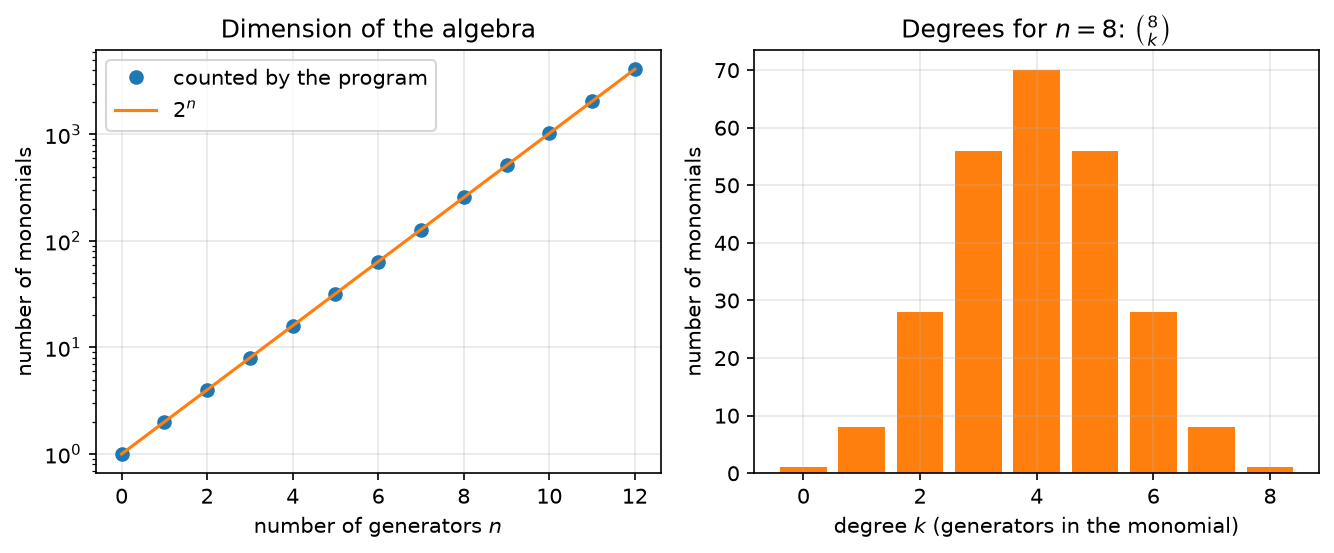

Figure 07a.1 saved as Revision/textbook/figures/07a_1_dimension_and_degrees.png


In [6]:
sizes = []  # the number of monomials for n = 0, 1, ..., 12
for n in range(13):
    everything = number(1)
    for i in range(n):
        everything = everything * (number(1) + theta(i))  # (1 + theta_i)
    sizes.append(len(everything.terms))
    if n == 8:
        degrees8 = Counter(len(monomial) for monomial in everything.terms)
        ones8 = all(value == 1 for value in everything.terms.values())
report("number of monomials for n = 12 generators", sizes[12])
check(sizes == [2 ** n for n in range(13)], "a Grassmann algebra with n generators "
      "has 2^n monomials (n = 0 to 12)")
check(ones8 and all(degrees8[k] == math.comb(8, k) for k in range(9)),
      "for n = 8 there are binom(8, k) monomials of degree k, each coefficient +1")

fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.8))
left.semilogy(range(13), sizes, "o", label="counted by the program")
left.semilogy(range(13), [2 ** n for n in range(13)], "-", label="$2^n$")
left.set_xlabel("number of generators $n$")
left.set_ylabel("number of monomials")
left.set_title("Dimension of the algebra")
left.legend()
right.bar(range(9), [degrees8[k] for k in range(9)], color="tab:orange")
right.set_xlabel("degree $k$ (generators in the monomial)")
right.set_ylabel("number of monomials")
right.set_title("Degrees for $n = 8$: $\\binom{8}{k}$")
fig.tight_layout()
save_figure(fig, "dimension_and_degrees",
            "Left: the number of monomials of a Grassmann algebra with $n$ "
            "generators, counted by the program (dots), and the formula $2^n$ "
            "(line), for $n = 0$ to $12$; horizontal axis $n$, vertical axis the "
            "count on a logarithmic scale, on which $2^n$ is a straight line. "
            "Right: for $n = 8$ the number of monomials of each degree $k$, the "
            "binomial coefficients 1, 8, 28, 56, 70, 56, 28, 8, 1, which add up to "
            "$2^8 = 256$. The algebra is finite because no generator can occur twice "
            "in a nonzero product.")

## 8. The multiplication table of three generators

With three generators the algebra has the eight monomials $1, \theta_0, \theta_1,
\theta_2, \theta_0\theta_1, \theta_0\theta_2, \theta_1\theta_2,
\theta_0\theta_1\theta_2$. The next cell computes the sign of the product of every
monomial (row) with every monomial (column): $+1$, $-1$, or 0 when they share a
generator. A product is nonzero when each of the three generators is in the row
monomial, in the column monomial, or in neither: $3^3 = 27$ possibilities. The
cell checks this count and draws the table as a heat map (Figure 2).

RESULT nonzero products among the 64 products of the 8 monomials = 27
PASS 27 = 3^3 of the 64 products of monomials of 3 generators are nonzero
PASS the table of the three generators is antisymmetric


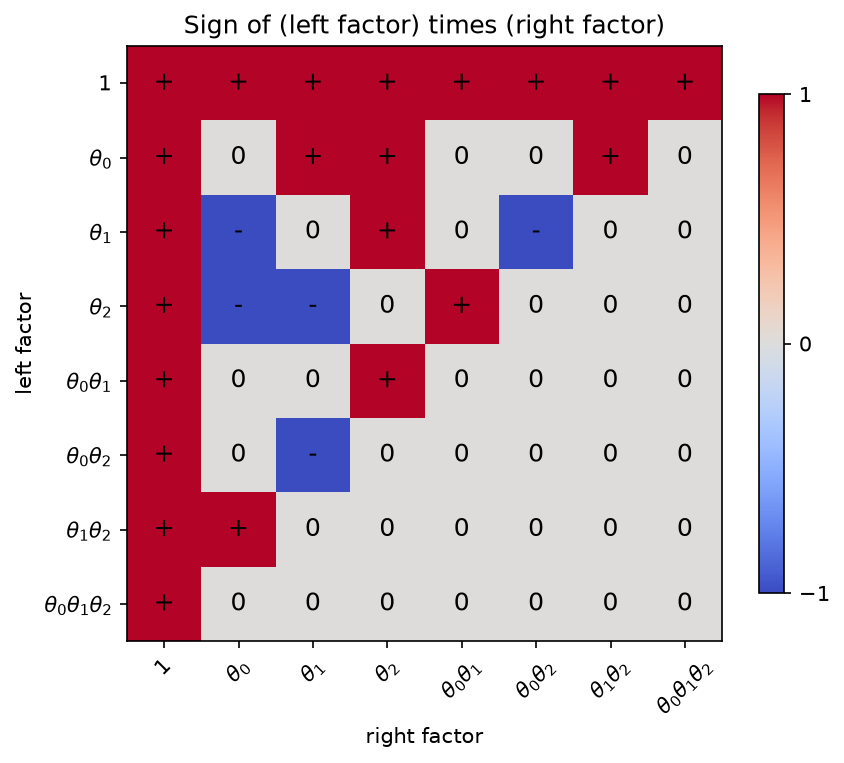

Figure 07a.2 saved as Revision/textbook/figures/07a_2_multiplication_signs.png


In [7]:
basis3 = [(), (0,), (1,), (2,), (0, 1), (0, 2), (1, 2), (0, 1, 2)]
names3 = ["$1$"] + ["$" + "".join(f"\\theta_{i}" for i in m) + "$" for m in basis3[1:]]
table = np.array([[shuffle_sign(row, column) for column in basis3] for row in basis3])
nonzero = int(np.count_nonzero(table))
report("nonzero products among the 64 products of the 8 monomials", nonzero)
check(nonzero == 27, "27 = 3^3 of the 64 products of monomials of 3 generators are "
      "nonzero")
check(np.array_equal(table[1:4, 1:4], -table[1:4, 1:4].T),
      "the table of the three generators is antisymmetric")

fig, ax = plt.subplots(figsize=(6.4, 5.4))
image = ax.imshow(table, cmap="coolwarm", vmin=-1, vmax=1)
for i in range(8):
    for j in range(8):
        ax.text(j, i, {1: "+", -1: "-", 0: "0"}[int(table[i, j])], ha="center",
                va="center", fontsize=12)
ax.set_xticks(range(8), names3, rotation=45)
ax.set_yticks(range(8), names3)
ax.set_xlabel("right factor")
ax.set_ylabel("left factor")
ax.set_title("Sign of (left factor) times (right factor)")
ax.grid(False)
fig.colorbar(image, ax=ax, ticks=[-1, 0, 1], shrink=0.8)
save_figure(fig, "multiplication_signs",
            "The multiplication table of the 8 monomials of a Grassmann algebra with "
            "three generators: row = left factor, column = right factor; the entry "
            "is the sign with which the product equals the sorted monomial "
            "(red $+1$, blue $-1$), and 0 (grey) when the two factors share a "
            "generator. The 27 nonzero entries are the ways of distributing the "
            "three generators over the two factors. The block of the three "
            "generators is antisymmetric: $\\theta_i\\theta_j = -\\theta_j\\theta_i$.")

## 9. Even and odd elements

Moving a monomial $X$ of degree $k$ past a monomial $Y$ of degree $l$ (with no
common generator) moves each of the $k$ generators past each of the $l$ others:
$kl$ exchanges. So

$$YX = (-1)^{kl}\, XY .$$

If $k$ or $l$ is even, the sign is $+1$: an even element commutes with everything.
If both are odd, the sign is $-1$: odd elements anticommute. The next cell measures
the sign for $k, l = 0, \dots, 4$ with $X = \theta_0\cdots\theta_{k-1}$ and $Y =
\theta_5\cdots\theta_{5+l-1}$, checks it against $(-1)^{kl}$ and draws Figure 3.
This is why the Lagrangian of dirac16complex, which contains the components in
pairs (it is even), behaves like an ordinary number in the order of factors.

PASS YX = (-1)^(k l) XY for degrees k, l = 0 .. 4


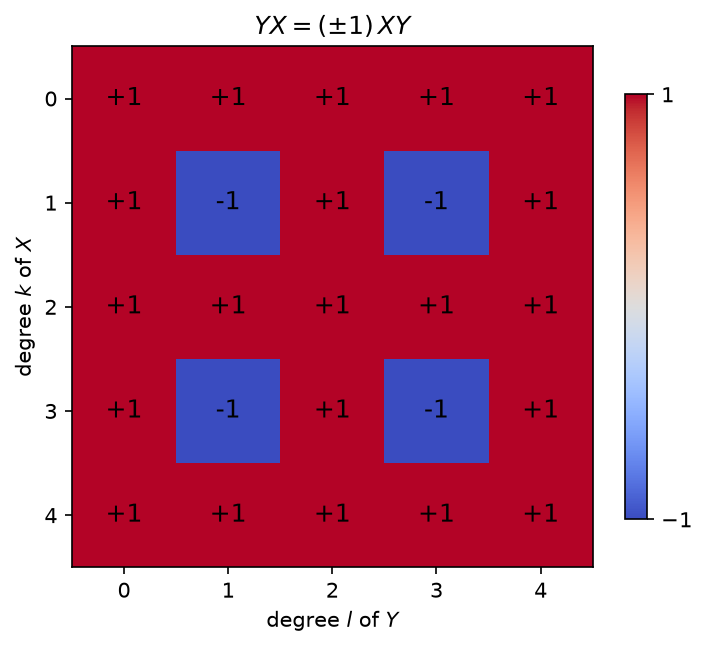

Figure 07a.3 saved as Revision/textbook/figures/07a_3_commutation_signs.png


In [8]:
signs = np.zeros((5, 5), dtype=int)
for k in range(5):
    for l in range(5):
        X = number(1)
        for i in range(k):
            X = X * theta(i)  # theta_0 ... theta_(k-1)
        Y = number(1)
        for i in range(l):
            Y = Y * theta(5 + i)  # theta_5 ... theta_(4+l)
        XY, YX = X * Y, Y * X
        (monomial, value), = XY.terms.items()  # XY is one monomial
        signs[k, l] = YX.terms[monomial] // value  # +1 or -1
expected = np.array([[(-1) ** (k * l) for l in range(5)] for k in range(5)])
check(np.array_equal(signs, expected), "YX = (-1)^(k l) XY for degrees k, l = 0 .. 4")

fig, ax = plt.subplots(figsize=(5.6, 4.6))
image = ax.imshow(signs, cmap="coolwarm", vmin=-1, vmax=1)
for k in range(5):
    for l in range(5):
        ax.text(l, k, f"{signs[k, l]:+d}", ha="center", va="center", fontsize=12)
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xlabel("degree $l$ of $Y$")
ax.set_ylabel("degree $k$ of $X$")
ax.set_title("$YX = (\\pm 1)\\, XY$")
ax.grid(False)
fig.colorbar(image, ax=ax, ticks=[-1, 1], shrink=0.8)
save_figure(fig, "commutation_signs",
            "The sign in $YX = \\pm XY$ for a monomial $X$ of degree $k$ (row) and "
            "a monomial $Y$ of degree $l$ (column) without a common generator, "
            "measured by the program for $k, l = 0$ to $4$. Red $+1$: they "
            "commute; blue $-1$: they anticommute. The pattern is $(-1)^{kl}$: only "
            "two odd monomials anticommute, and an even monomial (rows and columns "
            "0, 2, 4) commutes with everything.")

## 10. Conjugation reverses the order

For complex Grassmann numbers the generators come in pairs, $\theta_k$ and
$\bar\theta_k = \theta_k^*$. The conjugation exchanges the members of every pair,
conjugates every coefficient, and reverses every product:

$$(\theta_1\theta_2)^* = \theta_2^*\theta_1^* = \bar\theta_2\bar\theta_1 .$$

Why reverse? With this rule the conjugate of $\bar\theta\theta$ is
$\theta^*\bar\theta^* = \bar\theta\theta$: the product of a complex Grassmann
number with its conjugate is real, as for ordinary numbers. The function
`conjugate` below takes a list `partner`, with `partner[g]` the generator that
the conjugation assigns to generator `g`, reverses each monomial, replaces each
generator by its partner, sorts back with `sort_with_sign` and conjugates the
coefficient with sympy.

The cell first defines the helper `reproduces(report, name)`: it reads the Revision
report (a JSON file), makes sure that it contains the check `name` with the verdict
PASS, and returns the text that the PASS line prints after "reproduces". The cell
then checks the rules that the Revision record checks for its own algebras. For
the Wolfram test algebra (generators $\theta_1, \theta_2$ and
$\bar\theta_1, \bar\theta_2$, numbered 0, 1, 2, 3 here): anticommutation,
$\theta_i^2 = 0$, $(\theta_1\theta_2)^* = \bar\theta_2\bar\theta_1$ and
$(F^*)^* = F$. For the jet super-algebra of the sympy record, with 16 complex
components $\psi_A$ and their conjugates $\chi_A = \psi_A^*$ (numbered $A$ and
$16 + A$ here): $\psi\psi = 0$, $\psi_A\psi_B = -\psi_B\psi_A$,
$(\chi_A\psi_B)^* = \chi_B\psi_A$ (order reversal) and $(i\chi_A\psi_A)^* =
-i\chi_A\psi_A$.

In [9]:
def reproduces(report, name):
    """The text "<report>, check <name>" for a PASS line, after making sure that
    the Revision report (a JSON file) contains the check name with verdict PASS."""
    data = json.loads(repository_file(report).read_text(encoding="utf-8"))
    found = [item for item in data["checks"] if item["name"] == name]
    if len(found) != 1 or found[0]["verdict"].upper() != "PASS":
        raise ValueError(f"{name} is not a passing check of {report}")
    return f"{report}, check {name}"


WLREP = "Revision/theory/reports/wolfram-field-theory.json"
PYREP = "Revision/theory/reports/python-field-theory.json"


def conjugate(element, partner):
    """The conjugate of element: generator g -> partner[g], the order of every
    product reversed, every coefficient complex-conjugated."""
    result = Grassmann()
    for monomial, coefficient in element.terms.items():
        images = [partner[g] for g in reversed(monomial)]  # reversed order
        sign, ordered = sort_with_sign(images)  # back to increasing order
        if sign != 0:
            result.add(ordered, sign * sp.conjugate(coefficient))
    return result


# the Wolfram test algebra: 0 = theta_1, 1 = theta_2, 2 = thetabar_1, 3 = thetabar_2
PAIR4 = [2, 3, 0, 1]
th1, th2, tb1, tb2 = theta(0), theta(1), theta(2), theta(3)
general = (number(sp.Rational(1, 2) + 2 * sp.I) + th1.scaled(3 - sp.I)
           + (th2 * tb1).scaled(-4 * sp.I) + (th1 * th2 * tb2).scaled(7))
check((th1 * th2 + th2 * th1).is_zero() and (th1 * th1).is_zero()
      and (conjugate(th1 * th2, PAIR4) - tb2 * tb1).is_zero()
      and (conjugate(conjugate(general, PAIR4), PAIR4) - general).is_zero(),
      "anticommutation, theta^2 = 0, (theta_1 theta_2)* = thetabar_2 thetabar_1, "
      "(F*)* = F",
      record=reproduces(WLREP, "grassmann_algebra_structure"))

# the jet super-algebra of the sympy record: psi_A = generator A, chi_A = 16 + A
PAIR32 = [16 + A for A in range(16)] + list(range(16))
psi = [theta(A) for A in range(16)]
chi = [theta(16 + A) for A in range(16)]
rules = ((psi[0] * psi[0]).is_zero() and (psi[0] * psi[1] + psi[1] * psi[0]).is_zero()
         and (conjugate(chi[0] * psi[1], PAIR32) - chi[1] * psi[0]).is_zero()
         and (conjugate((chi[0] * psi[0]).scaled(sp.I), PAIR32)
              + (chi[0] * psi[0]).scaled(sp.I)).is_zero())
check(rules, "psi psi = 0, psi_A psi_B = -psi_B psi_A, (chi_A psi_B)* = chi_B "
      "psi_A, (i chi_A psi_A)* = -i chi_A psi_A",
      record=reproduces(PYREP, "superalgebra_axioms"))
check((conjugate(chi[3] * psi[3], PAIR32) - chi[3] * psi[3]).is_zero(),
      "chi_A psi_A (a component times its conjugate) is real")

PASS anticommutation, theta^2 = 0, (theta_1 theta_2)* = thetabar_2 thetabar_1, (F*)* = F
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    grassmann_algebra_structure
PASS psi psi = 0, psi_A psi_B = -psi_B psi_A, (chi_A psi_B)* = chi_B psi_A, (i chi_A
    psi_A)* = -i chi_A psi_A
     reproduces Revision/theory/reports/python-field-theory.json, check
    superalgebra_axioms
PASS chi_A psi_A (a component times its conjugate) is real


## 11. Left and right derivatives

The left derivative $\partial_L F/\partial\theta_k$ moves $\theta_k$ to the far
left of each monomial that contains it (a $-1$ for every generator passed) and
deletes it; the right derivative moves it to the far right. In a sorted monomial
$\theta_k$ stands at a position $p$ (counting from 0); moving it left passes $p$
generators, moving it right passes $\text{degree} - 1 - p$. Examples worked by
hand for $F = \theta_0\theta_1$: $\partial_L F/\partial\theta_0 = \theta_1$,
$\partial_L F/\partial\theta_1 = -\theta_0$ (write $F = -\theta_1\theta_0$),
$\partial_R F/\partial\theta_1 = \theta_0$, $\partial_R F/\partial\theta_0 =
-\theta_1$.

For an EVEN monomial of degree $n$ the two signs differ by
$(-1)^{(n-1-p) - p} = (-1)^{n-1} = -1$, so $\partial_R F = -\partial_L F$ for
every even $F$. The next cell defines both derivatives, checks the four examples,
the rule for even elements on a random even element, and the derivative rules of
the sympy record: for $x = \chi_0$, $a = \psi_0$, $y = \psi_1$ and $p = xay$:
$\partial_L p/\partial y = \partial_R p/\partial y = xa$ and $\partial_L
p/\partial a = \partial_R p/\partial a = -xy$; for $q = xa$: $\partial_L
q/\partial a = -x$ and $\partial_R q/\partial a = +x$.

In [10]:
def left_derivative(element, k):
    """d_L element / d theta_k: move theta_k to the far left, then delete it."""
    result = Grassmann()
    for monomial, coefficient in element.terms.items():
        if k in monomial:
            p = monomial.index(k)  # the number of generators to its left
            result.add(monomial[:p] + monomial[p + 1:], (-1) ** p * coefficient)
    return result


def right_derivative(element, k):
    """d_R element / d theta_k: move theta_k to the far right, then delete it."""
    result = Grassmann()
    for monomial, coefficient in element.terms.items():
        if k in monomial:
            p = monomial.index(k)
            passed = len(monomial) - 1 - p  # generators to its right
            result.add(monomial[:p] + monomial[p + 1:], (-1) ** passed * coefficient)
    return result


F = t0 * t1
check((left_derivative(F, 0) - t1).is_zero() and (left_derivative(F, 1) + t0).is_zero()
      and (right_derivative(F, 1) - t0).is_zero()
      and (right_derivative(F, 0) + t1).is_zero(),
      "the four derivatives of theta_0 theta_1 worked by hand")
even = Grassmann()
for trial in range(40):  # a random even element of the algebra of 8 generators
    size = 2 * int(rng.integers(1, 4))  # degree 2, 4 or 6
    monomial = tuple(sorted(rng.choice(8, size=size, replace=False)))
    even.add(monomial, int(rng.integers(-9, 10)))
check(all((right_derivative(even, k) + left_derivative(even, k)).is_zero()
          for k in range(8)), "d_R F = -d_L F for a random even element F")
x, a_, y = chi[0], psi[0], psi[1]  # x = chi_0 (generator 16), a = psi_0, y = psi_1
p_, q_ = x * a_ * y, x * a_
rules = ((left_derivative(p_, 1) - x * a_).is_zero()
         and (right_derivative(p_, 1) - x * a_).is_zero()
         and (left_derivative(p_, 0) + x * y).is_zero()
         and (right_derivative(p_, 0) + x * y).is_zero()
         and (left_derivative(q_, 0) + x).is_zero()
         and (right_derivative(q_, 0) - x).is_zero())
check(rules, "left and right derivatives with the Grassmann signs",
      record=reproduces(PYREP, "superalgebra_axioms"))

PASS the four derivatives of theta_0 theta_1 worked by hand
PASS d_R F = -d_L F for a random even element F
PASS left and right derivatives with the Grassmann signs
     reproduces Revision/theory/reports/python-field-theory.json, check
    superalgebra_axioms


## 12. Bilinear forms: when is $\Psi^\dagger M \Psi$ real?

Take a column $\Psi$ of $n$ complex Grassmann numbers (generators $\psi_A$, numbered
$A$) and its conjugate row $\Psi^\dagger$ (generators $\chi_A = \psi_A^*$, numbered
$n + A$). For a matrix $M$ of ordinary numbers the conjugation rules give, in two
lines,

$$\big(\Psi^\dagger M \Psi\big)^* = \sum_{A,B} \big(\chi_A M_{AB} \psi_B\big)^*
= \sum_{A,B} M_{AB}^*\, \chi_B \psi_A = \Psi^\dagger M^\dagger \Psi .$$

The first equality is the definition of the bilinear form; the second is the
conjugation rule $(\chi_A\psi_B)^* = \psi_B^*\chi_A^* = \chi_B\psi_A$ (order
reversed, partners exchanged) with the conjugated coefficient; the third renames
the summation indices and uses $(M^\dagger)_{BA} = M_{AB}^*$. So the form is real
exactly when $M$ is Hermitian, the same rule as for ordinary complex numbers. The
reversal of the order is what makes the rule come out the same. The next cell
checks this with $n = 4$ for a random Hermitian $M$ (real) and a random
non-Hermitian $M$ (not real).

In [11]:
def bilinear(row, M, column):
    """sum over A, B of row[A] M[A, B] column[B] (one factor from each side)."""
    total = Grassmann()
    for A in range(len(row)):
        for B in range(len(column)):
            if M[A, B] != 0:
                total = total + (row[A] * column[B]).scaled(M[A, B])
    return total


n4 = 4
psi4 = [theta(A) for A in range(n4)]  # psi_A: generators 0 .. 3
chi4 = [theta(n4 + A) for A in range(n4)]  # chi_A = psi_A*: generators 4 .. 7
PAIR8 = [n4 + A for A in range(n4)] + list(range(n4))
random_matrix = sp.Matrix(n4, n4, lambda i, j: int(rng.integers(-3, 4))
                          + sp.I * int(rng.integers(-3, 4)))
hermitian = random_matrix + random_matrix.H  # M + M^dagger is Hermitian
form_h = bilinear(chi4, hermitian, psi4)
form_n = bilinear(chi4, random_matrix, psi4)
check((conjugate(form_h, PAIR8) - form_h).is_zero(),
      "Psi^dagger M Psi is real for a Hermitian M")
not_hermitian = random_matrix.H != random_matrix  # True: M^dagger differs from M
check(not_hermitian and not (conjugate(form_n, PAIR8) - form_n).is_zero(),
      "Psi^dagger M Psi is not real for a non-Hermitian M")

PASS Psi^dagger M Psi is real for a Hermitian M
PASS Psi^dagger M Psi is not real for a non-Hermitian M


## 13. Real Grassmann columns and the author's matrix $C$

Now take a REAL column $\Theta = (\theta_0, \dots, \theta_{15})^T$ of 16 real
Grassmann generators (no conjugates at all) and the form $\Theta^T M \Theta =
\sum_{A,B} \theta_A M_{AB} \theta_B$. Exchanging the two odd factors and renaming
the indices gives, line by line,

$$\Theta^T M \Theta = \sum_{A,B} \theta_A M_{AB} \theta_B = -\sum_{A,B} \theta_B
M_{AB} \theta_A = -\sum_{A,B} \theta_A (M^T)_{AB} \theta_B = -\Theta^T M^T \Theta .$$

The second step is the anticommutation of $\theta_A$ and $\theta_B$; the third
renames $A \leftrightarrow B$ and uses $(M^T)_{AB} = M_{BA}$. Hence the symmetric
part of $M$ drops out: **for a real Grassmann column only the antisymmetric part of
$M$ survives, and $\Theta^T M \Theta = 0$ for every symmetric $M$.** For a real
column $q$ of ordinary numbers it is the other way round: $q^T M q = q^T M^T q$, so
only the symmetric part survives and $q^T M q = 0$ for every antisymmetric $M$.

The author's matrix $C$ is symmetric and each $C\gamma^{(a)}$ is antisymmetric.
The next cell reads $C$ and the eight gamma matrices from the Revision record
Revision/algebra/gammas.json, checks these two properties, and computes the nine
forms $\Theta^T C \Theta$ and $\Theta^T C \gamma^{(a)} \Theta$ ($a = x_1, \dots,
x_8$) both for real Grassmann $\Theta$ (with the program) and for real ordinary
numbers $q$ (with sympy), counting the monomials that survive.

In [12]:
gammas_file = "Revision/algebra/gammas.json"
fixture = json.loads(repository_file(gammas_file).read_text(encoding="utf-8"))
G = [np.array(g, dtype=int) for g in fixture["gamma"]]  # gamma^(x1) .. gamma^(x8)
C = np.array(fixture["C"], dtype=int)  # C = gamma^(x8) gamma^(x1) gamma^(x2) gamma^(x3)
check(np.array_equal(C, G[7] @ G[0] @ G[1] @ G[2]), "C = gamma^(x8) gamma^(x1) "
      "gamma^(x2) gamma^(x3) (read from Revision/algebra/gammas.json)")
check(np.array_equal(C.T, C) and np.array_equal(C @ C, np.eye(16, dtype=int))
      and all(np.array_equal((C @ g).T, -(C @ g)) for g in G),
      "C is symmetric, C^2 = 1, and every C gamma^(a) is antisymmetric",
      record=reproduces(PYREP, "C_properties"))

Theta = [theta(A) for A in range(16)]  # a real Grassmann column
q = sp.Matrix(sp.symbols("q0:16"))  # a real column of ordinary numbers
labels = ["$C$"] + [f"$C\\gamma^{{(x_{a + 1})}}$" for a in range(8)]
matrices = [sp.Matrix(C)] + [sp.Matrix(C @ g) for g in G]  # exact sympy matrices
grassmann_counts, commuting_counts = [], []
for M in matrices:
    grassmann_counts.append(len(bilinear(Theta, M, Theta).terms))
    form = sp.expand((q.T * M * q)[0, 0])
    commuting_counts.append(0 if form == 0 else len(sp.Add.make_args(form)))
say(f"monomials, real Grassmann: {grassmann_counts}")
say(f"monomials, real commuting: {commuting_counts}")

PASS C = gamma^(x8) gamma^(x1) gamma^(x2) gamma^(x3) (read from
    Revision/algebra/gammas.json)
PASS C is symmetric, C^2 = 1, and every C gamma^(a) is antisymmetric
     reproduces Revision/theory/reports/python-field-theory.json, check C_properties
monomials, real Grassmann: [0, 8, 8, 8, 8, 8, 8, 8, 8]
monomials, real commuting: [8, 0, 0, 0, 0, 0, 0, 0, 0]


The next cell checks the pattern and the coefficients: $\Theta^T C \Theta$ has no
monomial, while each $\Theta^T C\gamma^{(a)}\Theta$ has 8 monomials with
coefficients $\pm 2$ (each antisymmetric pair of entries $\pm1$ of $C\gamma^{(a)}$
gives $\theta_A\theta_B - \theta_B\theta_A = 2\theta_A\theta_B$). For real ordinary
numbers $q^T C q$ has 8 monomials and every $q^T C\gamma^{(a)} q$ vanishes. The
first of these facts is part of the Revision check that the Majorana-type
Lagrangian of a real anticommuting field has no mass term; the last is part of the
check that its contrast for commuting components states. Figure 4 shows the
counts and Figure 5 the matrices $C$ and $C\gamma^{(x_1)}$.

PASS real Grassmann: Theta^T C Theta = 0; each Theta^T C gamma^(a) Theta has 8 monomials
    with coefficients +-2
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    Majorana_Lg_total_derivative_grassmann
PASS real commuting: q^T C q has 8 monomials, every q^T C gamma^(a) q is 0
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    Majorana_Lg_commuting_control


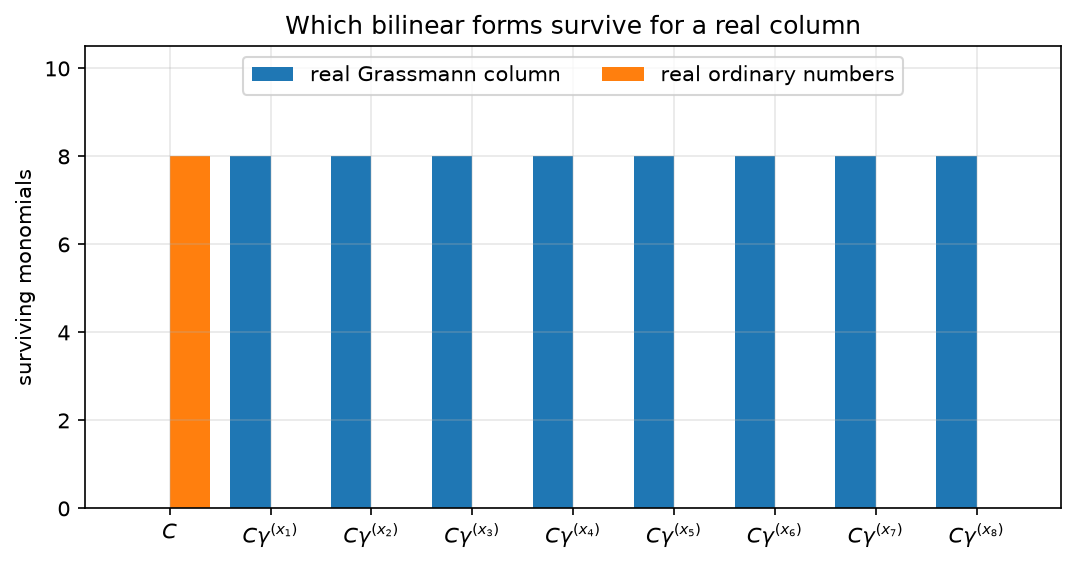

Figure 07a.4 saved as Revision/textbook/figures/07a_4_bilinear_survivors.png


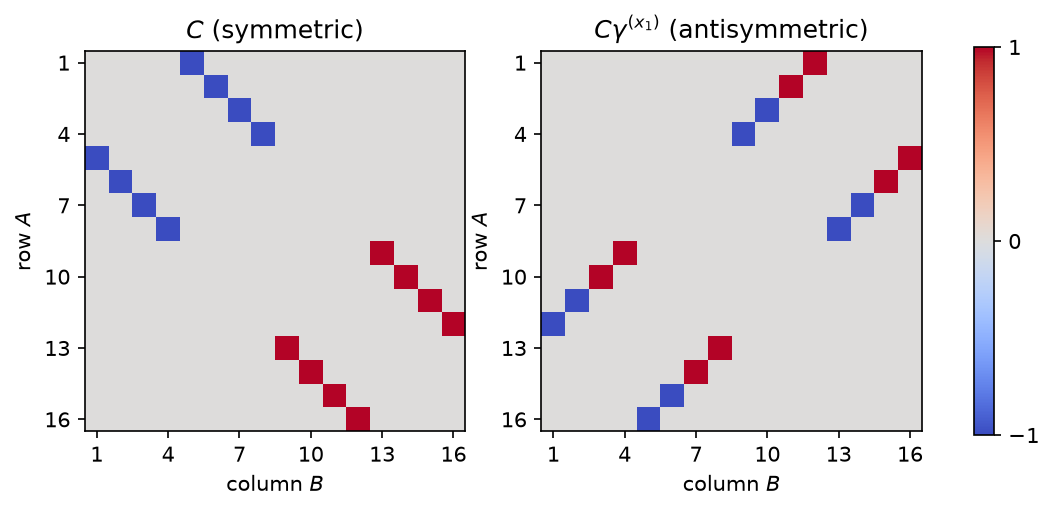

Figure 07a.5 saved as Revision/textbook/figures/07a_5_symmetric_antisymmetric.png


In [13]:
two = all(abs(value) == 2 for M in matrices[1:]
          for value in bilinear(Theta, M, Theta).terms.values())
check(grassmann_counts == [0] + [8] * 8 and two, "real Grassmann: Theta^T C Theta "
      "= 0; each Theta^T C gamma^(a) Theta has 8 monomials with coefficients +-2",
      record=reproduces(WLREP, "Majorana_Lg_total_derivative_grassmann"))
check(commuting_counts == [8] + [0] * 8, "real commuting: q^T C q has 8 monomials, "
      "every q^T C gamma^(a) q is 0",
      record=reproduces(WLREP, "Majorana_Lg_commuting_control"))

fig, ax = plt.subplots(figsize=(8.4, 4.0))
positions = np.arange(len(labels))
ax.bar(positions - 0.2, grassmann_counts, width=0.4, label="real Grassmann column")
ax.bar(positions + 0.2, commuting_counts, width=0.4, label="real ordinary numbers")
ax.set_xticks(positions, labels)
ax.set_ylabel("surviving monomials")
ax.set_ylim(0, 10.5)  # room for the legend above the bars
ax.set_title("Which bilinear forms survive for a real column")
ax.legend(loc="upper center", ncol=2)
save_figure(fig, "bilinear_survivors",
            "The number of monomials that survive in the bilinear form $v^T M v$ "
            "of a real 16-component column $v$, for the nine matrices $M = C$ "
            "and $M = C\\gamma^{(a)}$, $a = x_1, \\dots, x_8$ (horizontal axis), "
            "when $v$ consists of real Grassmann generators (blue) or of real "
            "ordinary numbers (orange). The symmetric $C$ survives only for "
            "ordinary numbers, the antisymmetric $C\\gamma^{(a)}$ only for "
            "Grassmann numbers: the two kinds of numbers keep opposite halves of a "
            "matrix.")

fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.2))
for ax, M, title in zip(axes, [C, C @ G[0]],
                        ["$C$ (symmetric)", "$C\\gamma^{(x_1)}$ (antisymmetric)"]):
    image = ax.imshow(M, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(0, 16, 3), [str(k + 1) for k in range(0, 16, 3)])
    ax.set_yticks(range(0, 16, 3), [str(k + 1) for k in range(0, 16, 3)])
    ax.set_xlabel("column $B$")
    ax.set_ylabel("row $A$")
    ax.set_title(title)
    ax.grid(False)
fig.colorbar(image, ax=axes, ticks=[-1, 0, 1], shrink=0.8)
save_figure(fig, "symmetric_antisymmetric",
            "The $16 \\times 16$ matrices $C$ (left) and $C\\gamma^{(x_1)}$ (right) "
            "read from the Revision record; row $A$ and column $B$ run from 1 to "
            "16; red $+1$, blue $-1$, grey 0. Each row has exactly one nonzero "
            "entry (both are signed permutation matrices). Mirroring $C$ in its "
            "diagonal gives the same colours (symmetric); mirroring "
            "$C\\gamma^{(x_1)}$ swaps red and blue (antisymmetric).")

## 14. The scalar density $S$ of a 16-component field and its powers

At one point the field dirac16complex consists of 16 complex Grassmann numbers. We
use 32 generators: $\chi_A = \Psi_A^*$ (numbers 0 to 15) and $\psi_A = \Psi_A$
(numbers 16 to 31). The scalar density is

$$S = \Psi^\dagger C \Psi = \sum_{A,B} \chi_A C_{AB} \psi_B .$$

Every row of $C$ has exactly one entry $\pm1$, in the column $\pi(A)$, so $S =
\sum_A C_{A\pi(A)}\, P_A$ is a sum of 16 pairs $P_A = \chi_A\psi_{\pi(A)}$ that
share no generator. Each pair is even, so the pairs commute with each other, and
$P_A^2 = 0$. In $S^k$ only products of $k$ DIFFERENT pairs survive, and each such
product appears $k!$ times (once for every order of its factors). Hence $S^k$ has
$\binom{16}{k}$ monomials with coefficients $\pm k!$, $S^{16}$ is a single
monomial, and $S^{17} = 0$. Consequence for the Lagrangian: every function of $S$
is a polynomial of degree at most 16, so the potential $U(S) = \frac{\lambda}{2}
S^2$ is a choice among finitely many terms. For ordinary commuting numbers the
same $S$ has powers that never vanish; $S^k$ then has $\binom{16 + k - 1}{k}$
monomials (the number of ways to choose $k$ pairs with repetition).

The next cell computes $S, S^2, \dots, S^{17}$ with the program (about one second),
checks the counts and the coefficients, checks the commuting counts with sympy for
$k \le 3$, and draws Figure 6.

In [14]:
S = Grassmann()
for A in range(16):
    for B in range(16):
        if C[A, B] != 0:
            S = S + (theta(A) * theta(16 + B)).scaled(int(C[A, B]))  # chi_A C psi_B
power = number(1)
counts, sizes_ok = [], True
for k in range(1, 18):
    power = power * S  # S^k
    counts.append(len(power.terms))
    sizes_ok = sizes_ok and all(abs(value) == math.factorial(k)
                                for value in power.terms.values())
report("monomials of S^k for k = 1 .. 8", counts[:8])
report("monomials of S^k for k = 9 .. 17", counts[8:])
check(counts[:16] == [math.comb(16, k) for k in range(1, 17)] and sizes_ok,
      "S^k has binom(16, k) monomials with coefficients +-k! (k = 1 .. 16)")
check(counts[16] == 0, "S^17 = 0: every function of S is a polynomial of degree <= 16")

chi_c, psi_c = sp.symbols("x0:16"), sp.symbols("y0:16")  # commuting stand-ins
S_commuting = sum(int(C[A, B]) * chi_c[A] * psi_c[B]
                  for A in range(16) for B in range(16) if C[A, B] != 0)
commuting = [len(sp.Add.make_args(sp.expand(S_commuting ** k))) for k in (1, 2, 3)]
check(commuting == [math.comb(16 + k - 1, k) for k in (1, 2, 3)],
      "commuting numbers: S^k has binom(15 + k, k) monomials (k = 1, 2, 3)")

RESULT monomials of S^k for k = 1 .. 8 = [16, 120, 560, 1820, 4368, 8008, 11440, 12870]
RESULT monomials of S^k for k = 9 .. 17 = [11440, 8008, 4368, 1820, 560, 120, 16, 1, 0]
PASS S^k has binom(16, k) monomials with coefficients +-k! (k = 1 .. 16)
PASS S^17 = 0: every function of S is a polynomial of degree <= 16
PASS commuting numbers: S^k has binom(15 + k, k) monomials (k = 1, 2, 3)


Figure 6 compares the two kinds of numbers. The next cell draws it.

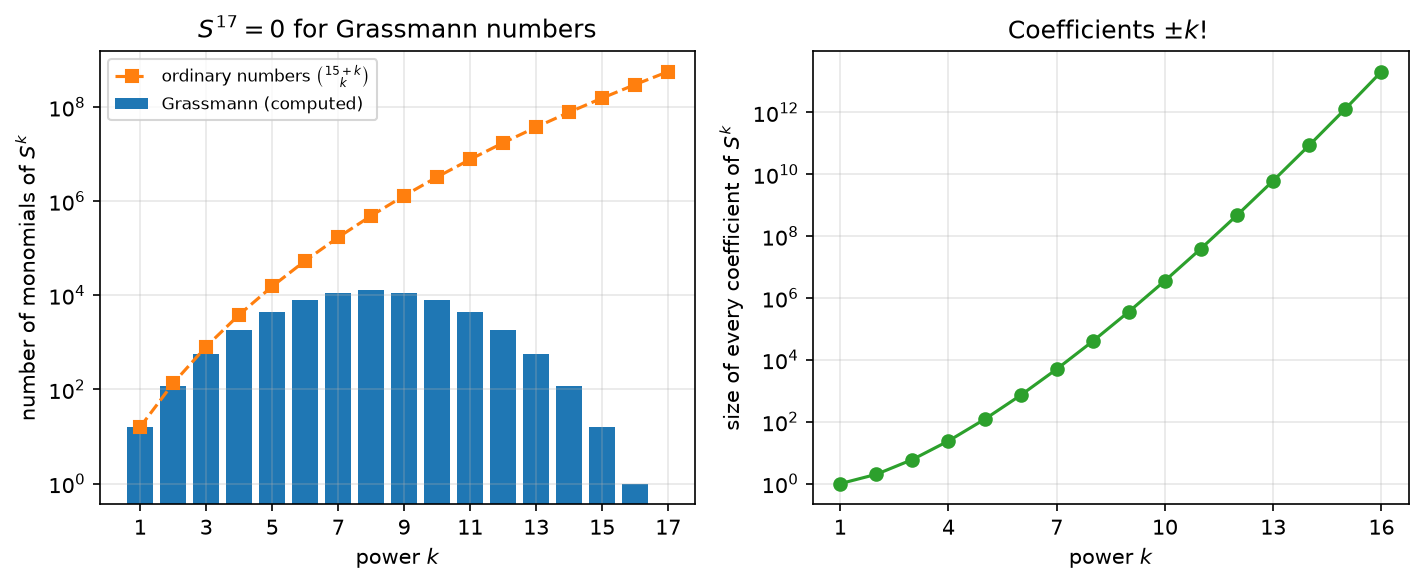

Figure 07a.6 saved as Revision/textbook/figures/07a_6_powers_of_s.png


In [15]:
ks = np.arange(1, 18)
fig, (left, right) = plt.subplots(1, 2, figsize=(9.6, 4.0))
left.bar(ks[:16], counts[:16], color="tab:blue", label="Grassmann (computed)")
left.plot(ks, [math.comb(15 + k, k) for k in ks], "s--", color="tab:orange",
          label="ordinary numbers $\\binom{15+k}{k}$")
left.set_yscale("log")
left.set_xticks(range(1, 18, 2))
left.set_xlabel("power $k$")
left.set_ylabel("number of monomials of $S^k$")
left.set_title("$S^{17} = 0$ for Grassmann numbers")
left.legend(fontsize=8)
right.semilogy(ks[:16], [math.factorial(k) for k in ks[:16]], "o-", color="tab:green")
right.set_xticks(range(1, 17, 3))
right.set_xlabel("power $k$")
right.set_ylabel("size of every coefficient of $S^k$")
right.set_title("Coefficients $\\pm k!$")
fig.tight_layout()
save_figure(fig, "powers_of_s",
            "Left: the number of monomials of $S^k$, the $k$-th power of the scalar "
            "density $S = \\Psi^\\dagger C\\Psi$ of a 16-component field at one "
            "point, for $k = 1$ to $17$ (logarithmic vertical axis). Blue bars: "
            "complex Grassmann components, computed by the program; the counts "
            "rise and fall as $\\binom{16}{k}$ and $S^{17} = 0$ (no bar). Orange "
            "squares: ordinary commuting components, $\\binom{15+k}{k}$, which "
            "grow without end. Right: every coefficient of $S^k$ is $\\pm k!$, "
            "from 1 to $16! \\approx 2.1 \\times 10^{13}$.")

## 15. The Revision test algebra with two generators

The Wolfram verifier of the Revision record does not give every component its own
generator. It uses an algebra with only two generators $\theta_1, \theta_2$ and
their conjugates $\bar\theta_1, \bar\theta_2$, and writes each component as
$\Psi_A = c_{A1}\theta_1 + c_{A2}\theta_2$ with ordinary complex coefficients. That
keeps the computation small and is still a genuine Grassmann field. Then

$$S = \Psi^\dagger C \Psi = \sum_{k,l} \bar\theta_k\theta_l\, \big(c_k^\dagger C
c_l\big),$$

so $S$ lives only on the four monomials $\bar\theta_k\theta_l$ (it is even),
$S^2$ only on $\theta_1\theta_2\bar\theta_1\bar\theta_2$, and $S^3 = 0$ because it
would need six different generators out of four. Hence in this test algebra the
most general potential is $U = u_1 S + \frac{\lambda}{2} S^2$. The next cell
builds such a field with random Gaussian-integer coefficients (fixed seed) and
checks all of this, and that $S$ is real ($C$ is real and symmetric, hence
Hermitian).

In [16]:
coefficients = [[int(rng.integers(-3, 4)) + sp.I * int(rng.integers(-3, 4))
                 for k in range(2)] for A in range(16)]
Psi = [th1.scaled(coefficients[A][0]) + th2.scaled(coefficients[A][1])
       for A in range(16)]
Psi_dagger = [conjugate(component, PAIR4) for component in Psi]
S2 = bilinear(Psi_dagger, sp.Matrix(C), Psi)  # S in the test algebra
shapes = sorted(S2.terms)
say(f"monomials of S (generator numbers): {shapes}")
say(f"monomials of S^2: {sorted((S2 * S2).terms)}")
check(all(len(m) == 2 and m[0] in (0, 1) and m[1] in (2, 3) for m in shapes)
      and (conjugate(S2, PAIR4) - S2).is_zero(),
      "S is a real even element on the monomials thetabar_k theta_l")
check(sorted((S2 * S2).terms) == [(0, 1, 2, 3)] and (S2 * S2 * S2).is_zero(),
      "S^2 != 0 lives on theta_1 theta_2 thetabar_1 thetabar_2 and S^3 = 0",
      record=reproduces(WLREP, "grassmann_algebra_structure"))

monomials of S (generator numbers): [(0, 2), (0, 3), (1, 2), (1, 3)]
monomials of S^2: [(0, 1, 2, 3)]
PASS S is a real even element on the monomials thetabar_k theta_l
PASS S^2 != 0 lives on theta_1 theta_2 thetabar_1 thetabar_2 and S^3 = 0
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    grassmann_algebra_structure


## 16. Field equations with Grassmann numbers: the oscillator

A field depends on a coordinate. To vary a Lagrangian we treat the value of a
variable and its derivative at one point as independent symbols (they are called
**jets**). Here the variable is a complex Grassmann number $\theta(t)$ of one
variable $t$; the generators are $\bar\theta$ (number 0), $\theta$ (1),
$\bar\theta'$ (2), $\theta'$ (3), and the second derivatives
$\bar\theta^{\prime\prime}$ (4), $\theta^{\prime\prime}$ (5); the prime is $d/dt$.
The **total derivative** $d/dt$ raises each generator by 2 (from $\theta$ to
$\theta'$, from $\theta'$ to $\theta^{\prime\prime}$) in each place, with the
product rule; it is even, so it needs no extra sign, but the raised generator may
have to be sorted back into place.

The Lagrangian of the oscillator,

$$L = \tfrac{i}{2}\big(\bar\theta\theta' - \bar\theta'\theta\big) -
\omega\,\bar\theta\theta ,$$

is real. Varying $\bar\theta$ from the left gives the Euler-Lagrange expression

$$\mathcal{E} = \frac{\partial_L L}{\partial\bar\theta} - \frac{d}{dt}\,
\frac{\partial_L L}{\partial\bar\theta'}
= \Big(\tfrac{i}{2}\theta' - \omega\theta\Big) - \frac{d}{dt}\Big(-\tfrac{i}{2}
\theta\Big) = i\theta' - \omega\theta .$$

The first term: $\bar\theta$ already stands on the left of $\bar\theta\theta'$
and $\bar\theta\theta$; the second: $-\frac{i}{2}\bar\theta'\theta$ has
$\bar\theta'$ on the left, its derivative is $-\frac{i}{2}\theta$, whose $d/dt$ is
$-\frac{i}{2}\theta'$. The field equation $i\theta' = \omega\theta$ has the same
form as for an ordinary complex oscillator. The next cell computes $\mathcal{E}$
with the program and checks that $L$ is real.

In [17]:
def total_derivative(element, step):
    """d/dt on jets: every generator g in every place becomes g + step (from a
    variable to its derivative), with the product rule; the raised monomial is
    sorted back with its sign."""
    result = Grassmann()
    for monomial, coefficient in element.terms.items():
        for place, g in enumerate(monomial):
            raised = monomial[:place] + (g + step,) + monomial[place + 1:]
            sign, ordered = sort_with_sign(raised)
            if sign != 0:
                result.add(ordered, sign * coefficient)
    return result


omega = sp.Symbol("omega", positive=True)  # the angular frequency
bar, th, bar_d, th_d = theta(0), theta(1), theta(2), theta(3)
L_osc = ((bar * th_d - bar_d * th).scaled(sp.I / 2) - (bar * th).scaled(omega))
E_osc = left_derivative(L_osc, 0) - total_derivative(left_derivative(L_osc, 2), 2)
PAIR6 = [1, 0, 3, 2, 5, 4]  # theta-bar <-> theta for the value and two derivatives
say(f"Euler-Lagrange expression (monomial: coefficient): {E_osc.terms}")
check((E_osc - (th_d.scaled(sp.I) - th.scaled(omega))).is_zero(),
      "the oscillator's Euler-Lagrange expression is i theta' - omega theta")
check((conjugate(L_osc, PAIR6) - L_osc).is_zero(), "the oscillator Lagrangian is real")

Euler-Lagrange expression (monomial: coefficient): {(3,): I, (1,): -omega}
PASS the oscillator's Euler-Lagrange expression is i theta' - omega theta
PASS the oscillator Lagrangian is real


The solution of $i\theta' = \omega\theta$ is $\theta(t) = e^{-i\omega t}\,\theta_0$
with a constant Grassmann generator $\theta_0$: an ordinary complex function times a
fixed generator. Indeed $i\theta' = i(-i\omega)e^{-i\omega t}\theta_0 = \omega
\theta$. The next cell checks this with sympy (the generator is a common factor and
drops out) and plots the ordinary function $e^{-i\omega t}$ for $\omega = 2$
(Figure 7).

PASS theta(t) = exp(-i omega t) theta_0 solves i theta' = omega theta


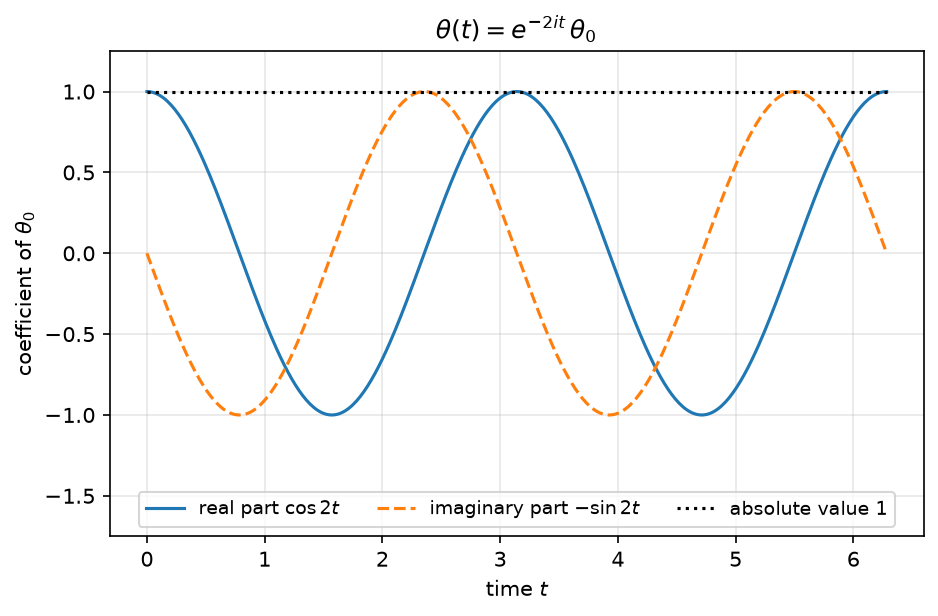

Figure 07a.7 saved as Revision/textbook/figures/07a_7_oscillator_solution.png


In [18]:
t = sp.Symbol("t", real=True)
solution = sp.exp(-sp.I * omega * t)  # theta(t) = solution * theta_0
residual = sp.simplify(sp.I * sp.diff(solution, t) - omega * solution)
check(residual == 0, "theta(t) = exp(-i omega t) theta_0 solves i theta' = omega theta")

times = np.linspace(0.0, 2.0 * np.pi, 400)
values = np.exp(-2.0j * times)  # omega = 2
fig, ax = plt.subplots()
ax.plot(times, values.real, label="real part $\\cos 2t$")
ax.plot(times, values.imag, "--", label="imaginary part $-\\sin 2t$")
ax.plot(times, np.abs(values), ":", color="black", label="absolute value 1")
ax.set_xlabel("time $t$")
ax.set_ylabel("coefficient of $\\theta_0$")
ax.set_title("$\\theta(t) = e^{-2it}\\,\\theta_0$")
ax.set_ylim(-1.75, 1.25)  # room for the legend below the curves
ax.legend(loc="lower center", ncol=3, fontsize=9)
save_figure(fig, "oscillator_solution",
            "The solution $\\theta(t) = e^{-i\\omega t}\\theta_0$ of the Grassmann "
            "oscillator for $\\omega = 2$ is an ordinary function times a fixed "
            "generator $\\theta_0$; the plot shows that function: its real part "
            "$\\cos 2t$ (solid), its imaginary part $-\\sin 2t$ (dashed) and its "
            "absolute value 1 (dotted), for $t$ from 0 to $2\\pi$ (pure numbers). "
            "The anticommuting nature sits in $\\theta_0$, not in the time "
            "dependence.")

## 17. A first-order kinetic term of real Grassmann fields

Now two REAL Grassmann fields $\theta_0(x)$, $\theta_1(x)$ of one coordinate $x$
(generators: $\theta_0$ = 0, $\theta_1$ = 1, $\theta_0'$ = 2, $\theta_1'$ = 3,
$\theta_0^{\prime\prime}$ = 4, $\theta_1^{\prime\prime}$ = 5) and the first-order
kinetic term with the antisymmetric matrix $A = \begin{pmatrix} 0 & 1 \\ -1 & 0
\end{pmatrix}$:

$$K_A = \theta^T A\, \theta' = \theta_0\theta_1' - \theta_1\theta_0' .$$

Moving $\theta_0'$ to the left in the second term (one exchange) gives
$K_A = \theta_0\theta_1' + \theta_0'\theta_1 = (\theta_0\theta_1)'$ by the
product rule, and $\theta^T A\theta = \theta_0\theta_1 - \theta_1\theta_0 =
2\theta_0\theta_1$. So $K_A = \frac12(\theta^T A\theta)'$ is a **total
derivative**, and a total derivative gives no field equation: both
Euler-Lagrange expressions vanish identically. With the symmetric identity matrix
instead, $K_I = \theta_0\theta_0' + \theta_1\theta_1'$ is not a derivative and its
Euler-Lagrange expression for $\theta_0$ is $\theta_0' - \frac{d}{dx}(-\theta_0) =
2\theta_0'$. For ORDINARY numbers $q_0, q_1$ the roles are exchanged: $K_A$ gives
the nonzero expressions $2q_1'$ and $-2q_0'$. This is the one-dimensional model of
the Majorana-type negative control of the Revision record (a real anticommuting
field with the antisymmetric kinetic matrices $C\gamma^\mu$ has no field equation),
which Notebook 07c computes in the author's metric. The next cell checks all of
it, with sympy for the ordinary numbers.

In [19]:
th0, th1_, th0_d, th1_d = theta(0), theta(1), theta(2), theta(3)
K_A = th0 * th1_d - th1_ * th0_d  # theta^T A theta' with A = ((0, 1), (-1, 0))
K_I = th0 * th0_d + th1_ * th1_d  # theta^T I theta'


def euler_lagrange(L, field):
    """dL/d(field) - d/dx dL/d(field') with left derivatives (field = 0 or 1)."""
    return left_derivative(L, field) - total_derivative(left_derivative(L, field + 2), 2)


check((K_A - total_derivative((th0 * th1_ - th1_ * th0).scaled(sp.Rational(1, 2)),
                              2)).is_zero(),
      "K_A = (1/2) d/dx (theta^T A theta): a total derivative")
check(euler_lagrange(K_A, 0).is_zero() and euler_lagrange(K_A, 1).is_zero(),
      "real Grassmann fields: both Euler-Lagrange expressions of K_A vanish")
check((euler_lagrange(K_I, 0) - th0_d.scaled(2)).is_zero(),
      "real Grassmann fields: K_I gives the expression 2 theta_0'")

from sympy.calculus.euler import euler_equations  # sympy's Euler-Lagrange

xs = sp.Symbol("x", real=True)
q0, q1 = sp.Function("q0")(xs), sp.Function("q1")(xs)  # two ordinary functions
K_A_commuting = q0 * sp.diff(q1, xs) - q1 * sp.diff(q0, xs)
equations = euler_equations(K_A_commuting, [q0, q1], xs)
expressions = [sp.simplify(equation.lhs - equation.rhs) for equation in equations]
say(f"ordinary numbers, Euler-Lagrange expressions of K_A: {expressions}")
check(sp.simplify(expressions[0] - 2 * sp.diff(q1, xs)) == 0
      and sp.simplify(expressions[1] + 2 * sp.diff(q0, xs)) == 0,
      "ordinary numbers: K_A gives the nonzero expressions 2 q1' and -2 q0'")

PASS K_A = (1/2) d/dx (theta^T A theta): a total derivative
PASS real Grassmann fields: both Euler-Lagrange expressions of K_A vanish
PASS real Grassmann fields: K_I gives the expression 2 theta_0'
ordinary numbers, Euler-Lagrange expressions of K_A: [2*Derivative(q1(x), x),
    -2*Derivative(q0(x), x)]
PASS ordinary numbers: K_A gives the nonzero expressions 2 q1' and -2 q0'


## 18. The last check

The last cell checks that the seven figure files exist and prints the number of
checks that passed.

In [20]:
names = ["dimension_and_degrees", "multiplication_signs", "commutation_signs",
         "bilinear_survivors", "symmetric_antisymmetric", "powers_of_s",
         "oscillator_solution"]
files = [f"{FIGURE_FOLDER}/07a_{k}_{name}.png" for k, name in enumerate(names, 1)]
check(all(output_file(path).is_file() for path in files),
      "all 7 figure files of this notebook exist")
all_checks_passed()

PASS all 7 figure files of this notebook exist
ALL 38 CHECKS PASSED (notebook 07a)


## 19. What this notebook showed

- A Grassmann algebra is completely fixed by $\theta_i\theta_j = -\theta_j\theta_i$:
  a product is the sorted monomial times the sign $(-1)^{\text{exchanges}}$, or 0
  when a generator repeats. With $n$ generators there are exactly $2^n$
  monomials, $\binom{n}{k}$ of degree $k$.
- Even elements commute with everything, odd ones anticommute
  ($YX = (-1)^{kl}XY$); the Lagrangian, which contains the field in pairs, is even.
- The conjugation reverses the order of products; with that rule a bilinear form
  $\Psi^\dagger M\Psi$ is real exactly when $M$ is Hermitian, for Grassmann and for
  ordinary numbers alike. For even elements the right derivative is minus the left
  derivative.
- For a REAL column the two kinds of numbers keep opposite halves of a matrix: real
  Grassmann numbers keep the antisymmetric part ($\Theta^T C\Theta = 0$, every
  $\Theta^T C\gamma^{(a)}\Theta$ survives), real ordinary numbers the symmetric
  part.
- The scalar density $S$ of the 16-component complex Grassmann field satisfies
  $S^{17} = 0$; $S^k$ has $\binom{16}{k}$ monomials with coefficients $\pm k!$. In
  the two-generator test algebra of the Revision record $S^3 = 0$ already.
- With Grassmann numbers written with every conjugate on the left, field equations
  keep their ordinary form (the oscillator gives $i\theta' = \omega\theta$); but a
  first-order kinetic term of REAL Grassmann fields with an antisymmetric matrix is
  a total derivative and gives no field equation. This is why the Lagrangian of
  dirac16complex uses the complex field with $\bar\Psi = \Psi^\dagger C$.
- The rules reproduce the Grassmann-algebra checks of the Revision record
  (superalgebra_axioms, grassmann_algebra_structure, C_properties, and the parts of
  Majorana_Lg_total_derivative_grassmann and Majorana_Lg_commuting_control that
  concern the bilinear forms).